# 链上流动性研究：数据图表与结果核验

这份 Notebook 用原始时间序列和已保存的研究结果，直观看五个问题：

1. 价格与池库存是否只是同步变化；
2. TURBO 的高累计撤出是否等于资金永久离场；
3. FTT、CEL、GALA 的同一变量是否得到一致结果；
4. 相关系数是否可能被少数点或大量零值影响；
5. GALA 是否验证了 FTT/CEL 中发现的目标代币库存现象。

> 图表输出已经保存在 Notebook 中。在 GitHub 打开时无需运行代码即可查看。价格统一使用 WETH 计价。

## 重点变量

| 变量 | 白话含义 | 主要比较对象 |
|---|---|---|
| `tvl_token_close` | 时间段末池内目标代币数量 | 同期价格 |
| `volume_turnover` | 成交量相对池储备的大小 | 之后的价格和 LP 活动 |
| `actual_transfer_net_ratio` | 目标代币真实净进入池的比例 | 未来 24 小时价格 |
| `net_lp_flow_ratio` | LP 加入减去移除后的净变化比例 | 未来 24 小时价格 |
| `gross_lp_activity_ratio` | LP 加入和移除的总活动比例 | 未来 24 小时价格波动 |
| `target_inventory_share` | LP 新增价值中目标代币一侧的占比 | 未来 24 小时价格 |
| `largest_add_tx_share` | 最大一笔交易占该小时全部 LP 添加的比例 | 正常期与事件期差异 |

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'notebooks/data/visual_review_time_series.csv').exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError('Run this notebook from the project repository.')

series = pd.read_csv(
    ROOT / 'notebooks/data/visual_review_time_series.csv',
    parse_dates=['bucket_start'],
)
ledger = pd.read_csv(ROOT / 'output-cross-case-synthesis/association_ledger.csv')
gala_features = pd.read_csv(
    ROOT / 'output-gala-inventory-validation/hourly_features.csv'
)
turbo_daily = pd.read_csv(
    ROOT / 'notebooks/data/turbo_anomaly_daily.csv',
    parse_dates=['date_utc'],
)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'uPEG': '#2563eb', 'TURBO': '#f59e0b', 'FTT': '#dc2626', 'CEL': '#7c3aed', 'GALA': '#059669'}

coverage = (series.groupby(['case', 'phase'])
            .agg(rows=('bucket_start', 'size'),
                 start=('bucket_start', 'min'),
                 end=('bucket_start', 'max'))
            .reset_index())
display(coverage)

,case,phase,rows,start,end
0,CEL,incident_preceding,721,2022-05-14 02:00:00+00:00,2022-06-13 02:00:00+00:00
1,FTT,incident_preceding,717,2022-10-09 19:00:00+00:00,2022-11-08 15:00:00+00:00
2,GALA,incident_preceding,721,2024-04-20 19:00:00+00:00,2024-05-20 19:00:00+00:00
3,TURBO,pilot,31,2026-07-21 00:00:00+00:00,2026-08-20 00:00:00+00:00
4,uPEG,pilot,169,2026-05-06 05:00:00+00:00,2026-05-13 05:00:00+00:00


## 图 1：uPEG 价格与池库存的同期关系

为了让两个不同单位的变量能画在同一张图中，把它们都换算成“起点 = 100”的指数。

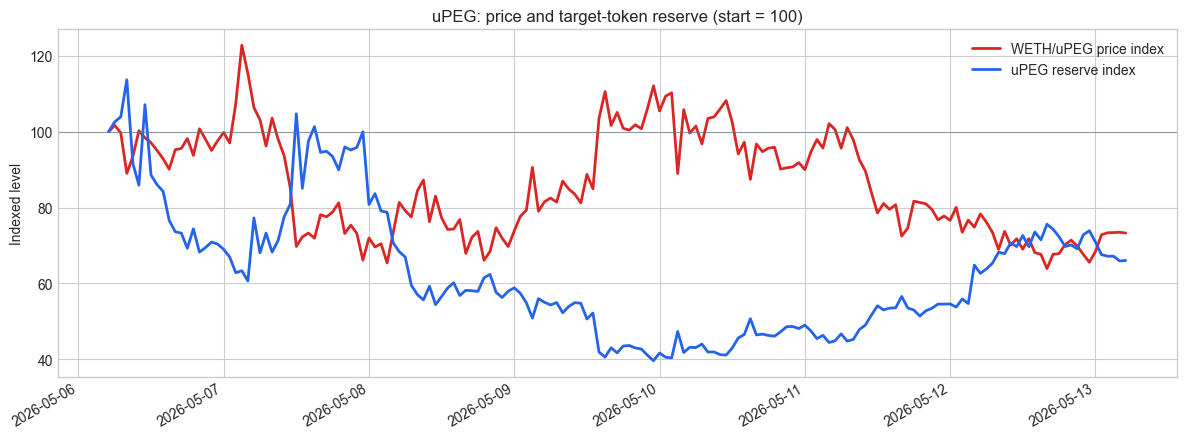

In [2]:
upeg = series[series['case'].eq('uPEG')].dropna(
    subset=['price_close', 'tvl_token_close']
).sort_values('bucket_start').copy()
upeg['price_index'] = upeg['price_close'] / upeg['price_close'].iloc[0] * 100
upeg['reserve_index'] = upeg['tvl_token_close'] / upeg['tvl_token_close'].iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(upeg['bucket_start'], upeg['price_index'], label='WETH/uPEG price index', color='#dc2626', linewidth=2)
ax.plot(upeg['bucket_start'], upeg['reserve_index'], label='uPEG reserve index', color='#2563eb', linewidth=2)
ax.axhline(100, color='#64748b', linewidth=0.8, alpha=0.6)
ax.set_title('uPEG: price and target-token reserve (start = 100)')
ax.set_ylabel('Indexed level')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**这张图说明什么：** 价格上涨时池内 uPEG 往往减少，价格下跌时往往增加。它说明价格和库存同步受交易池机制影响，但没有显示库存提前预测价格。

## 图 2：TURBO 累计撤出与真实净方向

左图比较累计移除和其中能匹配到快速重新建仓的数量；右图比较 LP 净变化和池地址真实 Transfer 净变化。单位均为百万 TURBO。

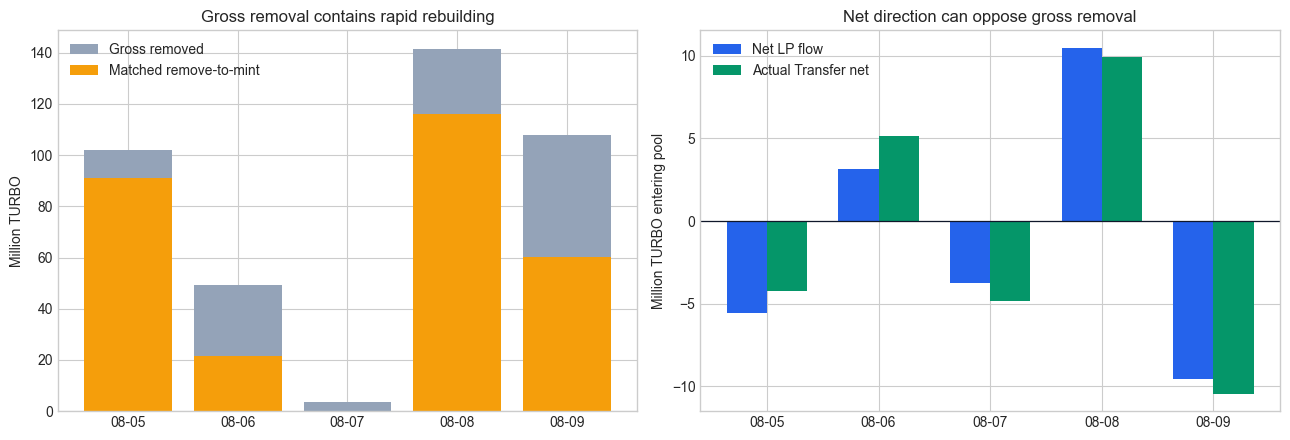

In [3]:
labels = turbo_daily['date_utc'].dt.strftime('%m-%d')
x = np.arange(len(turbo_daily))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(x, turbo_daily['gross_lp_remove_target'] / 1e6, color='#94a3b8', label='Gross removed')
axes[0].bar(x, turbo_daily['matched_removed_target'] / 1e6, color='#f59e0b', label='Matched remove-to-mint')
axes[0].set_title('Gross removal contains rapid rebuilding')
axes[0].set_ylabel('Million TURBO')
axes[0].set_xticks(x, labels)
axes[0].legend()

width = 0.36
axes[1].bar(x - width/2, turbo_daily['net_lp_flow_target'] / 1e6, width, color='#2563eb', label='Net LP flow')
axes[1].bar(x + width/2, turbo_daily['actual_transfer_net_to_pool_target'] / 1e6, width, color='#059669', label='Actual Transfer net')
axes[1].axhline(0, color='#0f172a', linewidth=0.9)
axes[1].set_title('Net direction can oppose gross removal')
axes[1].set_ylabel('Million TURBO entering pool')
axes[1].set_xticks(x, labels)
axes[1].legend()

plt.tight_layout()
plt.show()

**这张图说明什么：** 8 月 8 日累计移除很高，但 LP 净流和真实 Transfer 都是净进入池。五天累计移除中有 71.4% 能匹配到快速重新建仓候选，所以累计撤出更接近“调仓活动量”，不是永久离场比例。

## 图 3：FTT、CEL、GALA 的同变量结果是否一致

点表示相关系数，横线表示重复抽样得到的 95% 结果范围。横线穿过 0，表示方向仍不确定。

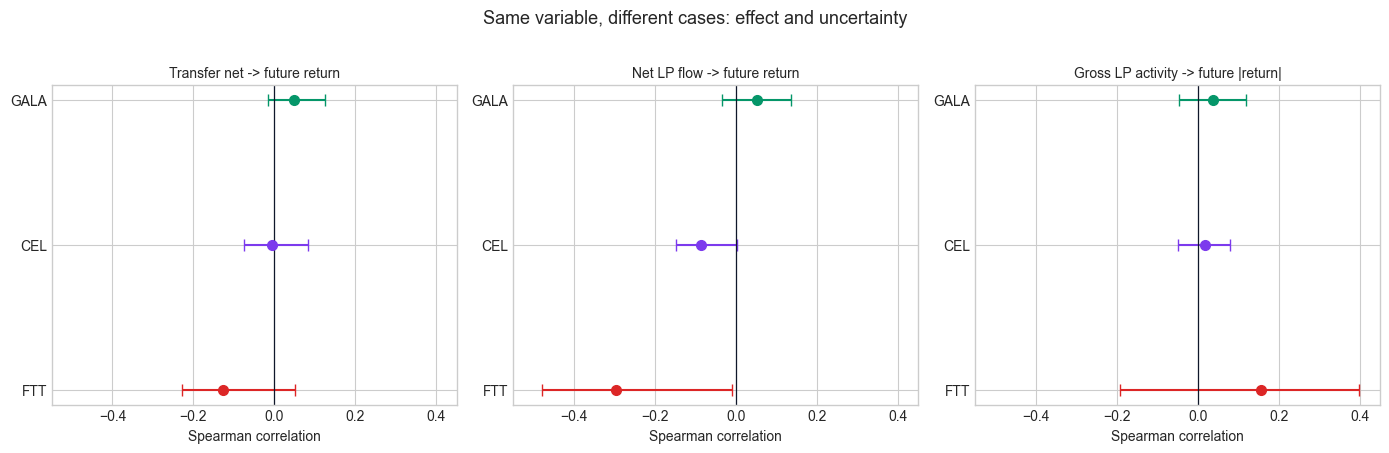

In [4]:
tests = [
    ('pool_transfer_net', 'Transfer net -> future return'),
    ('net_lp_flow', 'Net LP flow -> future return'),
    ('gross_lp_activity', 'Gross LP activity -> future |return|'),
]
cases = ['FTT', 'CEL', 'GALA']
subset = ledger[(ledger['phase'] == 'incident_preceding')].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharex=True)
for ax, (test_id, title) in zip(axes, tests):
    rows = subset[subset['test_id'].eq(test_id)].set_index('case').loc[cases]
    y = np.arange(len(cases))
    values = rows['spearman'].to_numpy()
    low = rows['bootstrap_ci_low'].to_numpy()
    high = rows['bootstrap_ci_high'].to_numpy()
    for i, case in enumerate(cases):
        ax.errorbar(values[i], y[i], xerr=[[values[i]-low[i]], [high[i]-values[i]]], fmt='o', color=COLORS[case], capsize=4, markersize=7)
    ax.axvline(0, color='#0f172a', linewidth=0.9)
    ax.set_yticks(y, cases)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Spearman correlation')
    ax.set_xlim(-0.55, 0.45)
fig.suptitle('Same variable, different cases: effect and uncertainty', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**这张图说明什么：** FTT 的净 LP 流负相关最明显，但 CEL 更弱，GALA 方向反转；其他变量的范围大多跨过 0。单个案例中的数字不能直接推广到其他代币。

## 图 4：不要只看相关系数——查看原始散点

每个点代表一个小时。横轴是该小时净 LP 流占上一小时池储备的百分比，纵轴是之后 24 小时价格涨跌百分比。黑线只是帮助看大致方向的直线，不是因果线；标题中的 `rho` 才是报告使用的 Spearman 相关系数。

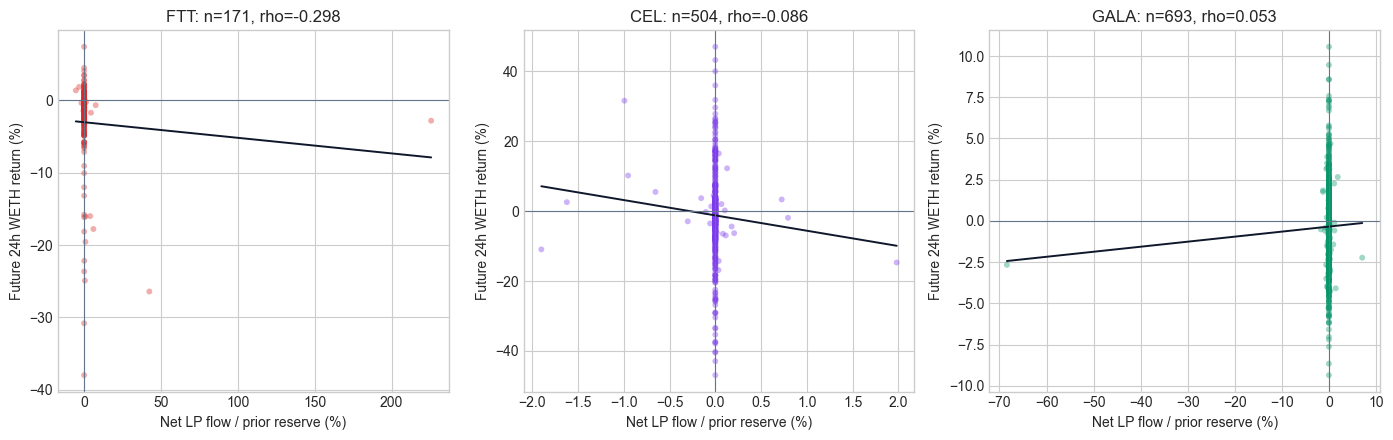

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
rho_lookup = subset[subset['test_id'].eq('net_lp_flow')].set_index('case')['spearman']
for ax, case in zip(axes, cases):
    data = series[series['case'].eq(case)].dropna(
        subset=['net_lp_flow_ratio', 'future_24h_log_return']
    ).copy()
    xval = data['net_lp_flow_ratio'].to_numpy() * 100
    yval = data['future_24h_log_return'].to_numpy() * 100
    ax.scatter(xval, yval, s=18, alpha=0.38, color=COLORS[case], edgecolors='none')
    if np.unique(xval).size > 1:
        slope, intercept = np.polyfit(xval, yval, 1)
        line_x = np.linspace(np.nanmin(xval), np.nanmax(xval), 100)
        ax.plot(line_x, slope * line_x + intercept, color='#0f172a', linewidth=1.4)
    ax.axhline(0, color='#64748b', linewidth=0.8)
    ax.axvline(0, color='#64748b', linewidth=0.8)
    ax.set_title(f'{case}: n={len(data)}, rho={rho_lookup[case]:.3f}')
    ax.set_xlabel('Net LP flow / prior reserve (%)')
    ax.set_ylabel('Future 24h WETH return (%)')
plt.tight_layout()
plt.show()

**这张图说明什么：** 大量小时集中在净 LP 流接近 0 的位置，同时存在少数很大的 LP 操作。FTT 的下降趋势没有在 CEL 和 GALA 中以同样强度出现，这正是不能只报告一个相关系数的原因。

## 图 5：GALA 是否验证了目标代币库存解释

左图比较 LP 新增中 GALA 一侧占比与未来价格，黑线只用于帮助观察大致方向；中图和右图比较事件前后目标代币占比与单笔集中度。

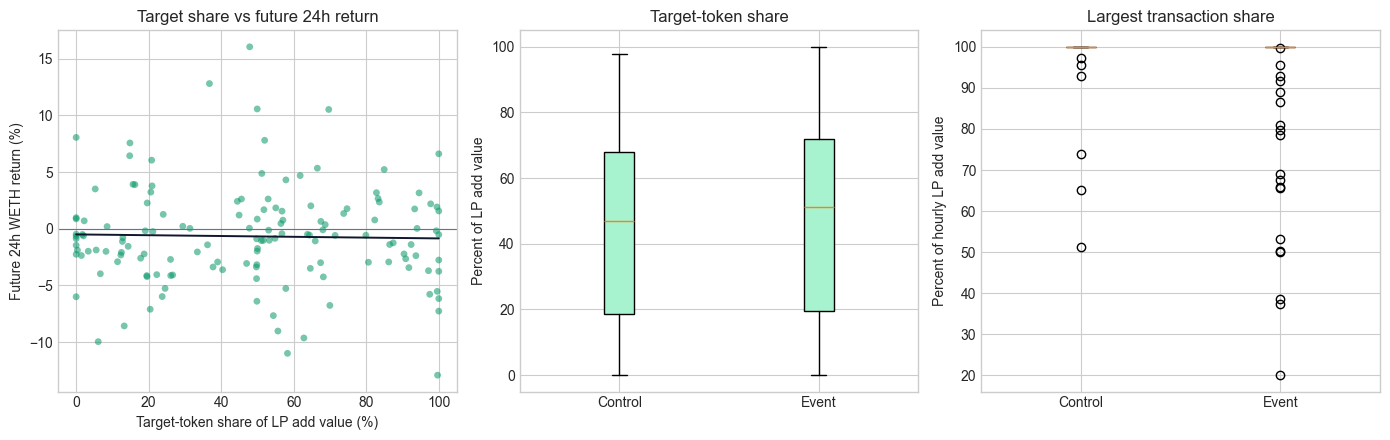

In [6]:
eligible = gala_features[
    gala_features['price_endpoint_observed'].eq(True)
].dropna(subset=['target_inventory_share', 'future_24h_log_return']).copy()
control = gala_features[gala_features['window'].eq('control')]
event = gala_features[gala_features['window'].eq('event')]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
xval = eligible['target_inventory_share'].to_numpy() * 100
yval = eligible['future_24h_log_return'].to_numpy() * 100
axes[0].scatter(xval, yval, color=COLORS['GALA'], alpha=0.55, s=24, edgecolors='none')
slope, intercept = np.polyfit(xval, yval, 1)
line_x = np.linspace(0, 100, 100)
axes[0].plot(line_x, slope * line_x + intercept, color='#0f172a', linewidth=1.4)
axes[0].axhline(0, color='#64748b', linewidth=0.8)
axes[0].set_title('Target share vs future 24h return')
axes[0].set_xlabel('Target-token share of LP add value (%)')
axes[0].set_ylabel('Future 24h WETH return (%)')

axes[1].boxplot(
    [control['target_inventory_share'].dropna() * 100, event['target_inventory_share'].dropna() * 100],
    tick_labels=['Control', 'Event'], patch_artist=True,
    boxprops={'facecolor': '#a7f3d0'}
)
axes[1].set_title('Target-token share')
axes[1].set_ylabel('Percent of LP add value')

axes[2].boxplot(
    [control['largest_add_tx_share'].dropna() * 100, event['largest_add_tx_share'].dropna() * 100],
    tick_labels=['Control', 'Event'], patch_artist=True,
    boxprops={'facecolor': '#bfdbfe'}
)
axes[2].set_title('Largest transaction share')
axes[2].set_ylabel('Percent of hourly LP add value')

plt.tight_layout()
plt.show()

**这张图说明什么：** 散点没有清楚的下降关系；事件期目标代币占比只略高，两个时期的单笔集中度都很高。GALA 没有把 FTT/CEL 的个案现象验证成稳定规律。

## 最终结论

图表支持以下白话结论：

- 价格与池库存确实会同步变化，但这不等于库存能够提前预测价格；
- 累计撤出会重复计算短期调仓，必须同时查看净 LP 流和真实 Transfer；
- FTT 的净 LP 流结果在 CEL 中明显变弱，在 GALA 中反向，不能跨案例推广；
- GALA 没有验证“目标代币库存占比可以解释未来下跌”的假设；
- 当前变量适合描述和核账，不适合单独作为崩盘预警器。

详细研究设计与限制见 `research-notes/data-analysis-research-summary-zh.md`。